# Part 4 — Methane sweep

In [1]:
# Parser from parse_MODTRAN.py (provided on Canvas)
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path



def is_header_line(line: str) -> bool:
    return "RADIANCE(WATTS/CM2-STER" in line

def is_block_terminator(line: str) -> bool:
    return line.strip().startswith("iv")

float_re = re.compile(r"[-+]?(?:\d+\.\d*|\.\d+|\d+)(?:[eEdD][-+]?\d+)?")

def try_parse_data_line(line: str):
    nums = float_re.findall(line)
    if len(nums) == 12:
        return list(map(lambda x: float(x.replace("D","E").replace("d","e")), nums))
    return None


def read_file(spath):
    text = spath.read_text(errors="ignore").splitlines()
    rows = []
    in_block = False
    skip_next = 0
    for ln in text:
        if is_header_line(ln):
            in_block = True
            skip_next = 2  # the two column header lines immediately after the title
            continue
        if in_block and skip_next > 0:
            skip_next -= 1
            continue
        if in_block:
            if is_block_terminator(ln):
                in_block = False
                continue
            parsed = try_parse_data_line(ln)
            if parsed is not None:
                rows.append(parsed)
    if not rows:
        raise RuntimeError("No radiance rows were detected.")
    cols = [
        "wn_cm1", "wav_um",
        "path_therm_cm1","path_therm_um",
        "surf_emis_cm1","surf_emis_um",
        "surf_refl_cm1","surf_refl_um",
        "total_cm1","total_um",
        "integral_cm1","trans"
    ]
    df = pd.DataFrame(rows, columns=cols)
    df.sort_values("wn_cm1", inplace=True)
    df.drop_duplicates(subset=["wn_cm1"], keep="last", inplace=True)
    df.sort_values("wav_um", inplace=True)
    return df

In [2]:
def BlackBody(w, T):
    # w: wavelength in meters, T: temperature in Kelvin
    # Returns spectral radiance in W m^-2 sr^-1 m^-1
    h = 6.62606957e-34  # joule·s
    c = 2.99792458e8  # Speed of light in m/s
    k = 1.38e-23  # Boltzmann constant in m^2 kg / s^2 / K
    return (2*h*c**2/w**5)*(1/(np.exp((h*c)/(w*k*T)) - 1))

In [3]:
def to_nm_units(df):
    # Returns (wavelength in nm, total radiance in W m^-2 sr^-1 nm^-1)
    # df has wav_um in µm and total_um in W cm^-2 sr^-1 µm^-1
    wl_nm = df["wav_um"].values*1e3  # µm -> nm
    rad = df["total_um"].values*1e4*1e-3  # cm^-2 -> m^-2, µm^-1 -> nm^-1
    return wl_nm, rad

In [4]:
def read_flux(spath):
    # Upward IR flux in W m^-2: pi * integrated radiance (W cm^-2 sr^-1 in the raw output) * 1e4
    m = re.search(r"INTEGRATED RADIANCE =\s*([\d.E+-]+)", spath.read_text(errors="ignore"))
    return float(m.group(1))*np.pi*1e4

In [5]:
# MODTRAN runs: same setup as Part 2, looking down from 100 km, CO2 = 427 ppm, only CH4 changed
ch4_values = ["0", "0.5", "1.0", "1.5", "1.9", "2.5", "3.0", "4.0", "5.0"]  # ppm, as written in the file names
ch4_spectra = {float(c): read_file(Path(f"data/ch4_sweep/CH4_{c}.txt")) for c in ch4_values}

ch4_table = pd.DataFrame({
    "CH4 (ppm)": [float(c) for c in ch4_values],
    "IR out (W m^-2)": [read_flux(Path(f"data/ch4_sweep/CH4_{c}.txt")) for c in ch4_values],
})
ch4_table["Change from 0 ppm (W m^-2)"] = ch4_table["IR out (W m^-2)"] - ch4_table["IR out (W m^-2)"].iloc[0]
ch4_table.round(2)

,CH4 (ppm),IR out (W m^-2),Change from 0 ppm (W m^-2)
0,0.0,291.41,0.00
1,0.5,290.41,-1.01
2,1.0,289.91,-1.51
3,1.5,289.53,-1.88
4,1.9,289.28,-2.14
5,2.5,288.96,-2.45
6,3.0,288.74,-2.67
7,4.0,288.34,-3.08
8,5.0,288.02,-3.39


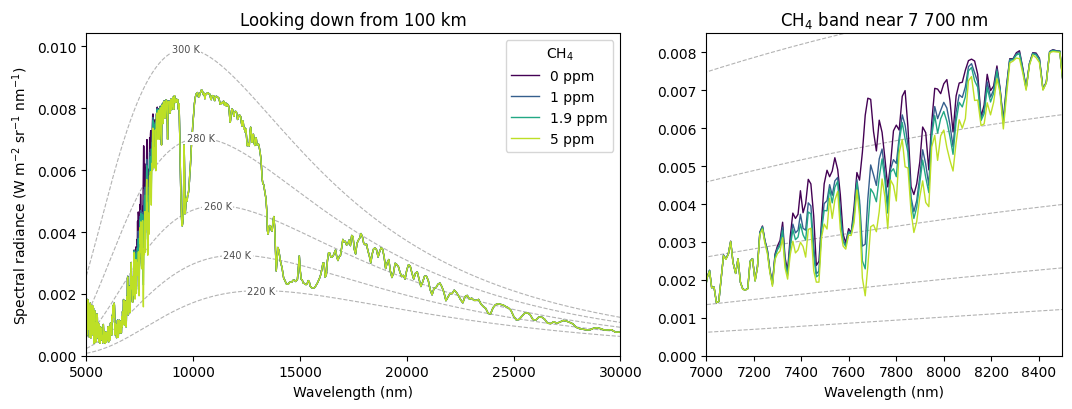

In [6]:
bb_temps = [220, 240, 260, 280, 300]  # K
wl_bb = np.linspace(5000, 30000, 500)  # nm
ch4_selected = [0, 1.0, 1.9, 5.0]  # ppm
colors = plt.cm.viridis(np.linspace(0, 0.9, len(ch4_selected)))

fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [3, 2]})

for ax in (ax_full, ax_zoom):
    for T in bb_temps:
        bb = BlackBody(wl_bb*1e-9, T)*1e-9  # per m -> per nm
        ax.plot(wl_bb, bb, color="0.7", lw=0.8, ls="--")
    for c, col in zip(ch4_selected, colors):
        wl, rad = to_nm_units(ch4_spectra[c])
        ax.plot(wl, rad, lw=1.0, color=col, label=f"{c:g} ppm")
    ax.set_xlabel("Wavelength (nm)")

for T in bb_temps:
    wl_peak = 2.898e6/T  # nm
    ax_full.text(wl_peak, BlackBody(wl_peak*1e-9, T)*1e-9, f"{T} K", fontsize=7, color="0.3",
                 ha="center", va="center", bbox=dict(facecolor="white", edgecolor="none", pad=1))

ax_full.set_xlim(5000, 30000)
ax_full.set_ylim(bottom=0)
ax_full.set_ylabel("Spectral radiance (W m$^{-2}$ sr$^{-1}$ nm$^{-1}$)")
ax_full.set_title("Looking down from 100 km")
ax_full.legend(title="CH$_4$")

# zoom on the CH4 band near 7.7 µm
ax_zoom.set_xlim(7000, 8500)
ax_zoom.set_ylim(0, 0.0085)
ax_zoom.set_title("CH$_4$ band near 7 700 nm")

plt.tight_layout()
plt.savefig("figures/part4_ch4_spectra.png", dpi=200)
plt.show()

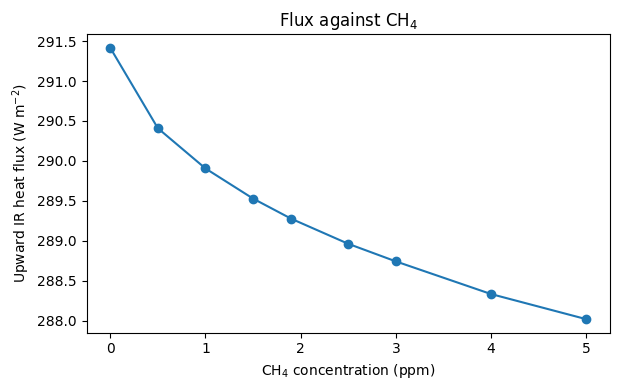

In [7]:
ch4 = ch4_table["CH4 (ppm)"].values
flux_ch4 = ch4_table["IR out (W m^-2)"].values

plt.figure(figsize=(6.3, 4.0))
plt.plot(ch4, flux_ch4, "o-")
plt.xlabel("CH$_4$ concentration (ppm)")
plt.ylabel("Upward IR heat flux (W m$^{-2}$)")
plt.title("Flux against CH$_4$")
plt.tight_layout()
plt.savefig("figures/part4_ch4_flux.png", dpi=200)
plt.show()

## Comparison with the CO₂ sweep from Part 3

CH4: reduction = 1.49 * CH4^0.53
CH4, 1.5 to 2.5 ppm: -0.57 W m^-2 per ppm
CO2, 400 to 500 ppm: -0.0097 W m^-2 per ppm
Ratio CH4/CO2 per ppm: 58
CH4 doubled, 2.5 to 5.0 ppm: -0.94 W m^-2
CO2 doubled, 400 to 800 ppm: -3.02 W m^-2


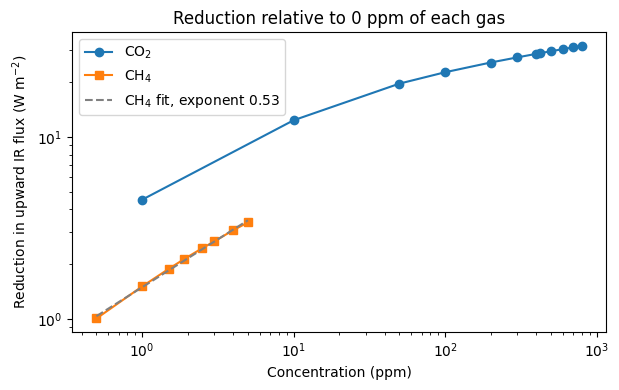

In [8]:
co2 = np.array([0, 1, 10, 50, 100, 200, 300, 400, 425, 500, 600, 700, 800])  # ppm
flux_co2 = np.array([read_flux(Path(f"data/co2_sweep/CO2_{c}.txt")) for c in co2])

# reduction in outgoing flux relative to the run with none of that gas
red_ch4 = flux_ch4[0] - flux_ch4
red_co2 = flux_co2[0] - flux_co2

# power law fit for methane: reduction = a * CH4^b (b = 0.5 would be a square-root response)
b, ln_a = np.polyfit(np.log(ch4[1:]), np.log(red_ch4[1:]), 1)
print(f"CH4: reduction = {np.exp(ln_a):.2f} * CH4^{b:.2f}")

def flux_at(c, conc, flux):
    return flux[np.argmin(np.abs(conc - c))]

# sensitivity near present-day concentrations
s_ch4 = flux_at(2.5, ch4, flux_ch4) - flux_at(1.5, ch4, flux_ch4)  # per 1 ppm
s_co2 = (flux_at(500, co2, flux_co2) - flux_at(400, co2, flux_co2))/100  # per 1 ppm
print(f"CH4, 1.5 to 2.5 ppm: {s_ch4:.2f} W m^-2 per ppm")
print(f"CO2, 400 to 500 ppm: {s_co2:.4f} W m^-2 per ppm")
print(f"Ratio CH4/CO2 per ppm: {s_ch4/s_co2:.0f}")
print(f"CH4 doubled, 2.5 to 5.0 ppm: {flux_at(5.0, ch4, flux_ch4) - flux_at(2.5, ch4, flux_ch4):.2f} W m^-2")
print(f"CO2 doubled, 400 to 800 ppm: {flux_at(800, co2, flux_co2) - flux_at(400, co2, flux_co2):.2f} W m^-2")

plt.figure(figsize=(6.3, 4.0))
plt.loglog(co2[1:], red_co2[1:], "o-", label="CO$_2$")
plt.loglog(ch4[1:], red_ch4[1:], "s-", label="CH$_4$")
c_fit = np.linspace(ch4[1], ch4[-1], 50)
plt.loglog(c_fit, np.exp(ln_a)*c_fit**b, color="0.5", ls="--", label=f"CH$_4$ fit, exponent {b:.2f}")
plt.xlabel("Concentration (ppm)")
plt.ylabel("Reduction in upward IR flux (W m$^{-2}$)")
plt.title("Reduction relative to 0 ppm of each gas")
plt.legend()
plt.tight_layout()
plt.savefig("figures/part4_ch4_co2_comparison.png", dpi=200)
plt.show()